# **Smartphone Image with Dirty Lenses (SIDL) Dataset: NAFNet Online Demo**


---



# 로컬 환경 설정 테스트


In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_arch_list())

2.12.0.dev20260408+cu128
True
NVIDIA GeForce RTX 5060
['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [2]:
x = torch.rand(3,3).cuda()
print(x)

# 1. NAFNet 환경 설치
# 2. YAML 경로 수정
# 3. train 실행

tensor([[0.2404, 0.8575, 0.7609],
        [0.9845, 0.8287, 0.1477],
        [0.7089, 0.8855, 0.8823]], device='cuda:0')


* 로컬 이미지 테스트 ( 속도 테스트 )

(512, 512, 3)
time: 0.024999141693115234


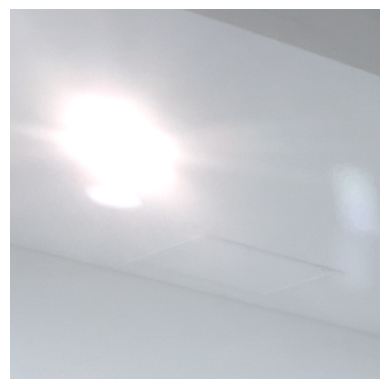

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = r"G:\.shortcut-targets-by-id\16M_VTZyM-1-mp0UmdTs2kbK0_ro4GkE9\mixed\easy\input\Case125_FD_001.png"

img = Image.open(img_path)

import time
import cv2

start = time.time()

img = cv2.imread(img_path)

print(img.shape)
print("time:", time.time() - start)

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
from dataset_config import get_train_root

water_root = get_train_root("water")

print(water_root)

print("\n")

for p in water_root.iterdir():
    print(p)

G:\.shortcut-targets-by-id\1EEFsAOy22ywrq7X8hbG_yng8rxLpRcoh\water


G:\.shortcut-targets-by-id\1EEFsAOy22ywrq7X8hbG_yng8rxLpRcoh\water\target
G:\.shortcut-targets-by-id\1EEFsAOy22ywrq7X8hbG_yng8rxLpRcoh\water\input


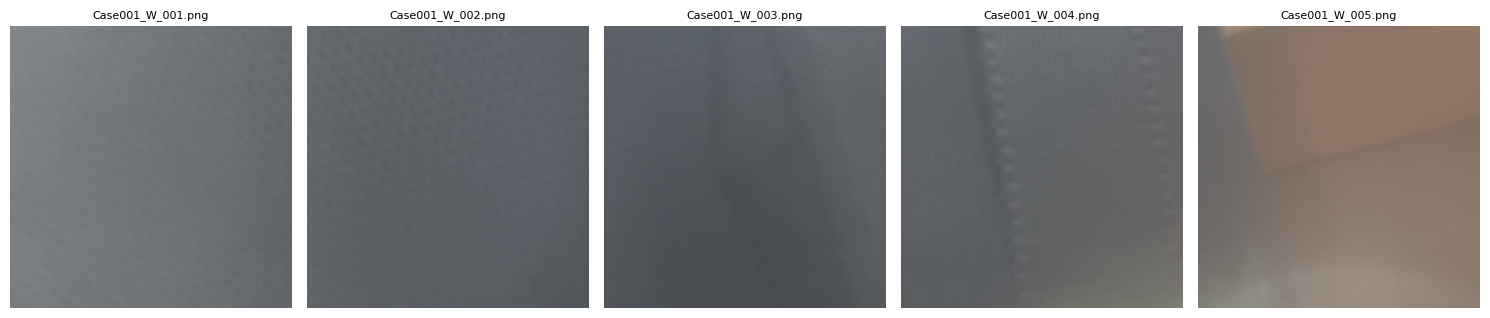

In [5]:
from pathlib import Path
from dataset_config import get_train_root

import cv2
import matplotlib.pyplot as plt

# =========================================================
# water train input 경로
# =========================================================

water_root = get_train_root("water")
input_dir = water_root / "input"

# =========================================================
# 이미지 5개 가져오기
# =========================================================

image_paths = sorted(input_dir.glob("*.png"))[:5]

# =========================================================
# 시각화
# =========================================================

plt.figure(figsize=(15, 5))

for idx, img_path in enumerate(image_paths):

    # 이미지 읽기
    img = cv2.imread(str(img_path))

    # BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # subplot
    plt.subplot(1, 5, idx + 1)

    plt.imshow(img)

    plt.title(img_path.name, fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import cv2
import time

train_root = Path(r"G:\.shortcut-targets-by-id\1EEFsAOy22ywrq7X8hbG_yng8rxLpRcoh\water")

input_dir = train_root / "input"

images = sorted(input_dir.glob("*.png"))

print("이미지 개수:", len(images))

start = time.time()

img = cv2.imread(str(images[0]))

print("shape:", img.shape)

print("time:", time.time() - start)

이미지 개수: 10752
shape: (512, 512, 3)
time: 0.030625581741333008


Disable distributed.
Path already exists. Rename it to tb_logger\NAFNet-SIDL-water-width16_100iter_archived_20260527_013300
.. cosineannealingLR


2026-05-27 01:33:00,863 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)
    
Version Information: 
	BasicSR: 1.2.0+2b4af71
	PyTorch: 2.12.0.dev20260408+cu128
	TorchVision: 0.27.0.dev20260407+cu128
2026-05-27 01:33:00,864 INFO: 
  path:[
    root: c:\dnn\deeplearning\nafnet
    pretrain_network_g: None
    strict_load_g: True
    resume_state: None
    experiments_root: c:\dnn\deeplearning\nafnet\experiments\NAFNet-SIDL-water-width16_100i

: 

In [3]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.append(r"C:\DNN\deepLearning\NAFNet")

# **Make custom yml file for training**

In [2]:
from dataset_config import (
    get_train_root,
    get_valid_root
)

import os

# =========================================================
# 실험 설정
# =========================================================

tasks = [
    'water',
    # 'finger',
    # 'dust',
    'mixed',
    # 'scratch'
]

difficulties = [
    'easy',
    'medium',
    'hard'
]

# =========================================================
# 공통 하이퍼파라미터
# =========================================================

WIDTH = 16
BATCH_SIZE = 64
GT_SIZE = 64
TOTAL_ITER = 20000

# =========================================================
# 실험 저장 경로
# =========================================================

experiment_root = r"C:/DNN/deepLearning/NAFNet_experiments"

os.makedirs(experiment_root, exist_ok=True)

# =========================================================
# YAML 저장 경로
# =========================================================

out_dir = r"C:/DNN/deepLearning/sidl_options/train"

os.makedirs(out_dir, exist_ok=True)

# =========================================================
# YAML 자동 생성
# =========================================================

for task in tasks:

    for difficulty in difficulties:

        # -------------------------------------------------
        # 데이터 경로
        # -------------------------------------------------

        train_root = get_train_root(task)
        valid_root = get_valid_root(task)

        train_gt = (train_root / "target").as_posix()
        train_lq = (train_root / "input").as_posix()

        valid_gt = (valid_root / difficulty / "target").as_posix()
        valid_lq = (valid_root / difficulty / "input").as_posix()

        # -------------------------------------------------
        # 실험 이름
        # -------------------------------------------------

        EXP_NAME = f"Residual-NAFNet-{task}-{difficulty}-w{WIDTH}"

        # -------------------------------------------------
        # YAML 템플릿
        # -------------------------------------------------

        template = f"""
path:
  root: C:/DNN/deepLearning/NAFNet
  pretrain_network_g: ~
  strict_load_g: true
  resume_state: ~

name: {EXP_NAME}

model_type: ImageRestorationModel

scale: 1
num_gpu: 1
manual_seed: 42

datasets:

  train:
    name: sidl-{task}-train
    type: PairedImageDataset

    dataroot_gt: {train_gt}
    dataroot_lq: {train_lq}

    io_backend:
      type: disk

    gt_size: {GT_SIZE}

    use_flip: true
    use_rot: true
    use_shuffle: true

    num_worker_per_gpu: 4
    batch_size_per_gpu: {BATCH_SIZE}

  val:
    name: sidl-{task}-{difficulty}-val
    type: PairedImageDataset

    dataroot_gt: {valid_gt}
    dataroot_lq: {valid_lq}

    io_backend:
      type: disk

network_g:
  type: NAFNetLocal

  width: {WIDTH}

  enc_blk_nums: [1, 1, 1, 8]
  middle_blk_num: 1
  dec_blk_nums: [1, 1, 1, 1]

train:

  optim_g:
    type: AdamW

    lr: !!float 1e-4

    weight_decay: !!float 1e-4

    betas: [0.9, 0.9]

  scheduler:
    type: TrueCosineAnnealingLR

    T_max: {TOTAL_ITER}

    eta_min: !!float 1e-7

  total_iter: {TOTAL_ITER}

  warmup_iter: -1

  pixel_opt:
    type: PSNRLoss

    loss_weight: 1

    reduction: mean

val:

  val_freq: !!float 1000

  save_img: true

  metrics:

    psnr:
      type: calculate_psnr
      crop_border: 0
      test_y_channel: false

    ssim:
      type: calculate_ssim
      crop_border: 0
      test_y_channel: false

logger:

  print_freq: !!float 100

  save_checkpoint_freq: !!float 1000

  use_tb_logger: true

  wandb:
    project: ~

    resume_id: ~

dist_params:

  backend: gloo

  port: 29500
"""

        # -------------------------------------------------
        # YAML 저장
        # -------------------------------------------------

        out_path = os.path.join(
            out_dir,
            f"{EXP_NAME}.yml"
        )

        with open(out_path, 'w', encoding='utf-8') as f:
            f.write(template)

        print(f"✅ 생성 완료: {out_path}")

✅ 생성 완료: C:/DNN/deepLearning/sidl_options/train\Residual-NAFNet-water-easy-w16.yml
✅ 생성 완료: C:/DNN/deepLearning/sidl_options/train\Residual-NAFNet-water-medium-w16.yml
✅ 생성 완료: C:/DNN/deepLearning/sidl_options/train\Residual-NAFNet-water-hard-w16.yml
✅ 생성 완료: C:/DNN/deepLearning/sidl_options/train\Residual-NAFNet-mixed-easy-w16.yml
✅ 생성 완료: C:/DNN/deepLearning/sidl_options/train\Residual-NAFNet-mixed-medium-w16.yml
✅ 생성 완료: C:/DNN/deepLearning/sidl_options/train\Residual-NAFNet-mixed-hard-w16.yml


# **Training NAFNet for a Specific Task**

---



* 이게 학습하는 코드인데 이걸 하기 전의 설정은 위의 yml을 업데이트 하고 코드를 돌려야함

* 자동 실험기기

In [1]:
from pathlib import Path

root = Path(
    r"G:/.shortcut-targets-by-id"
)

targets = list(root.rglob("desktop.ini"))
thumbs = list(root.rglob("Thumbs.db"))

print("desktop.ini:", len(targets))
print("Thumbs.db:", len(thumbs))

for f in targets + thumbs:
    try:
        print("삭제:", f)
        f.unlink()
    except Exception as e:
        print("실패:", f, e)

desktop.ini: 0
Thumbs.db: 0


In [1]:
from pathlib import Path
import subprocess
import os

os.chdir(r"C:/DNN/deepLearning/NAFNet")

yaml_dir = Path(
    r"C:/DNN/deepLearning/sidl_options/train"
)

yaml_files = sorted(
    yaml_dir.glob("*.yml")
)

print(f"총 {len(yaml_files)}개 실험 실행 예정")

for yaml_file in yaml_files:

    print("\n" + "="*60)
    print(f"실행 중: {yaml_file.name}")
    print("="*60)

    cmd = [
        "python",
        "basicsr/train.py",
        "-opt",
        str(yaml_file)
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True
    )

    print("\nSTDOUT =====================")
    print(result.stdout)

    print("\nSTDERR =====================")
    print(result.stderr)

    print("\nRETURN CODE:", result.returncode)

    print(f"\n✅ 완료: {yaml_file.name}")

총 3개 실험 실행 예정

실행 중: NAFNet-mixed-easy-w16.yml

STDOUT =====================
Disable distributed.
Path already exists. Rename it to tb_logger\NAFNet-mixed-easy-w16_archived_20260604_094627
.. cosineannealingLR


STDERR =====================
2026-06-04 09:46:27,321 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)
    
Version Information: 
	BasicSR: 1.2.0+2b4af71
	PyTorch: 2.12.0.dev20260408+cu128
	TorchVision: 0.27.0.dev20260407+cu128
202

# **테스트 하기**

* 여기서는 우리가 커스텀 실험 계획서를 만들게 하는거임

* 패스 설정 잘 되어있는지 확인하기 

In [1]:
from path_config import *

model_dir = get_model_dir(
    'mixed',
    'easy'
)

print(model_dir)
print(model_dir.exists())

print(list(model_dir.glob('*.pth')))

C:\DNN\deepLearning\NAFNet\experiments\NAFNet-mixed-easy-w16\models
True
[WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_1000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_10000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_11000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_12000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_13000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_14000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_15000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_16000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_17000.pth'), WindowsPath('C:/DNN/deepLea

In [2]:
from pathlib import Path

from make_testYML import build_test_yml

from path_config import (
    TASK,
    DIFFICULTIES,
    YML_ROOT,
    get_model_dir
)


TARGET_ITERS = {
    5000,
    10000,
    15000,
    20000
}

# =========================================================
# GENERATE
# =========================================================

def generate_test_ymls():

    print('START')

    for difficulty in DIFFICULTIES:

        print(f'DIFFICULTY: {difficulty}')

        model_dir = get_model_dir(
            TASK,
            difficulty
        )

        print(model_dir)

        ckpt_list = sorted(
            model_dir.glob('*.pth')
        )

        print(ckpt_list)

        for ckpt_path in ckpt_list:

            try:
                iteration = int(
                    ckpt_path.stem.split('_')[-1]
                )
            except ValueError:
                continue

            if iteration not in TARGET_ITERS:
                continue

            print(ckpt_path)

            yml_text = build_test_yml(
                TASK,
                difficulty,
                ckpt_path,
                width=16
            )

            save_dir = (
                YML_ROOT /
                TASK /
                difficulty
            )

            print(save_dir)

            save_dir.mkdir(
                parents=True,
                exist_ok=True
            )

            save_path = (
                save_dir /
                f'Baseline_{ckpt_path.stem}.yml'
            )

            print(save_path)

            with open(
                save_path,
                'w',
                encoding='utf-8'
            ) as f:

                f.write(yml_text)

            print(
                f'SAVED: {save_path}'
            )


# =========================================================
# MAIN
# =========================================================
if __name__ == '__main__':

    generate_test_ymls()

START
DIFFICULTY: easy
C:\DNN\deepLearning\NAFNet\experiments\NAFNet-mixed-easy-w16\models
[WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_1000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_10000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_11000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_12000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_13000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_14000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_15000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_16000.pth'), WindowsPath('C:/DNN/deepLearning/NAFNet/experiments/NAFNet-mixed-easy-w16/models/net_g_17000.pth'), WindowsPa

In [3]:
from pathlib import Path
import subprocess

TEST_ROOTS = [
    Path(r'C:\DNN\deepLearning\sidl_options\test\mixed'),
    Path(r'C:\DNN\deepLearning\sidl_options\test\water')
]

NAFNET_ROOT = r'C:\DNN\deepLearning\NAFNet'

for TEST_ROOT in TEST_ROOTS:

    print('\n' + '#' * 80)
    print(f'DATASET: {TEST_ROOT.name}')
    print('#' * 80)

    yml_list = sorted(TEST_ROOT.rglob('*.yml'))

    print(f'TOTAL YAML FILES: {len(yml_list)}')

    for yml_path in yml_list:

        print('\n' + '=' * 80)
        print(
            f'TESTING: '
            f'{TEST_ROOT.name}/'
            f'{yml_path.relative_to(TEST_ROOT)}'
        )
        print('=' * 80)

        yml_abs_path = str(
            yml_path.resolve()
        )

        cmd = [
            'python',
            'basicsr/test.py',
            '-opt',
            yml_abs_path
        ]

        result = subprocess.run(
            cmd,
            cwd=NAFNET_ROOT,
            capture_output=True,
            text=True
        )

        print(result.stdout)

        if result.stderr.strip():

            print('\n[STDERR]')
            print(result.stderr)

        print(
            f'\nRETURN CODE: '
            f'{result.returncode}'
        )


################################################################################
DATASET: mixed
################################################################################
TOTAL YAML FILES: 6

TESTING: mixed/easy\Baseline_net_g_5000.yml
Disable distributed.
 load net keys <built-in method keys of collections.OrderedDict object at 0x0000025CCD90F440>


[STDERR]
2026-06-08 02:59:53,229 INFO: 
                ____                _       _____  ____
               / __ ) ____ _ _____ (_)_____/ ___/ / __ \
              / __  |/ __ `// ___// // ___/\__ \ / /_/ /
             / /_/ // /_/ /(__  )/ // /__ ___/ // _, _/
            /_____/ \__,_//____//_/ \___//____//_/ |_|
     ______                   __   __                 __      __
    / ____/____   ____   ____/ /  / /   __  __ _____ / /__   / /
   / / __ / __ \ / __ \ / __  /  / /   / / / // ___// //_/  / /
  / /_/ // /_/ // /_/ // /_/ /  / /___/ /_/ // /__ / /<    /_/
  \____/ \____/ \____/ \____/  /_____/\____/ \___//_/|_|  (_)


# **Efficiency Check**

benchmark 코드임.

즉 복원 성능(PSNR) 측정이 아니라:

연산량(FLOPs)
파라미터 수
추론 속도(latency)

측정용.

In [ ]:
import os
import sys
import time
import torch
import yaml
import pandas as pd

from calflops import calculate_flops

# =========================================================
# NAFNet PATH
# =========================================================

NAFNET_ROOT = r"C:\DNN\deepLearning\NAFNet"

sys.path.append(NAFNET_ROOT)

from basicsr.models import create_model

# =========================================================
# YAML PATH
# =========================================================
# 아무 yml 하나만 사용
# 구조 정보만 필요하기 때문
# =========================================================

YAML_PATH = (
    r"C:\DNN\deepLearning\sidl_options\test\water\easy"
    r"\net_g_5000.yml"
)

# =========================================================
# EXPERIMENT ROOT
# =========================================================

EXP_ROOT = (
    r"C:\DNN\deepLearning\NAFNet\experiments"
)

# =========================================================
# LOAD YAML
# =========================================================

with open(YAML_PATH, 'r') as f:
    opt = yaml.safe_load(f)

opt['is_train'] = False
opt['dist'] = False

# =========================================================
# RESULT
# =========================================================

results = []

# =========================================================
# SEARCH EXPERIMENTS
# =========================================================

for exp_name in os.listdir(EXP_ROOT):

    exp_path = os.path.join(EXP_ROOT, exp_name)

    if not os.path.isdir(exp_path):
        continue

    # =====================================================
    # difficulty parsing
    # =====================================================

    exp_lower = exp_name.lower()

    if "easy" in exp_lower:
        difficulty = "easy"

    elif "medium" in exp_lower:
        difficulty = "medium"

    elif "hard" in exp_lower:
        difficulty = "hard"

    else:
        difficulty = "unknown"

    # =====================================================
    # model folder
    # =====================================================

    models_path = os.path.join(
        exp_path,
        "models"
    )

    if not os.path.isdir(models_path):
        continue

    print("\n" + "=" * 60)
    print("EXPERIMENT :", exp_name)
    print("DIFFICULTY :", difficulty)
    print("=" * 60)

    # =====================================================
    # SORT MODEL FILES
    # =====================================================

    model_list = sorted(
        os.listdir(models_path),
        key=lambda x: (
            999999
            if "latest" in x
            else int(
                x.replace("net_g_", "")
                 .replace(".pth", "")
            )
        )
    )

    # =====================================================
    # MODEL LOOP
    # =====================================================

    for model_file in model_list:

        if not model_file.endswith(".pth"):
            continue

        ckpt_path = os.path.join(
            models_path,
            model_file
        )

        print("\nMODEL :", model_file)

        # =================================================
        # epoch parse
        # =================================================

        epoch = "latest"

        if "latest" not in model_file:

            try:
                epoch = int(
                    model_file.replace("net_g_", "")
                              .replace(".pth", "")
                )

            except:
                epoch = -1

        # =================================================
        # checkpoint load
        # =================================================

        if 'path' not in opt:
            opt['path'] = {}

        opt['path']['pretrain_network_g'] = ckpt_path

        # =================================================
        # build model
        # =================================================

        model_wrapper = create_model(opt)

        net_g = model_wrapper.net_g.eval().cuda()

        # =================================================
        # dummy input
        # =================================================

        input_shape = (1, 3, 512, 512)

        dummy_input = torch.randn(
            input_shape,
            device='cuda'
        )

        # =================================================
        # FLOPS / PARAMS
        # =================================================

        with torch.no_grad():

            flops, gmacs, params = calculate_flops(
                model=net_g,
                input_shape=input_shape,
                output_as_string=True,
                output_precision=4
            )

        # =================================================
        # WARMUP
        # =================================================

        for _ in range(10):

            with torch.no_grad():

                _ = net_g(dummy_input)

        torch.cuda.synchronize()

        # =================================================
        # LATENCY
        # =================================================

        N_RUNS = 100

        start = time.perf_counter()

        with torch.no_grad():

            for _ in range(N_RUNS):

                _ = net_g(dummy_input)

        torch.cuda.synchronize()

        end = time.perf_counter()

        latency_ms = (
            (end - start) / N_RUNS * 1000
        )

        # =================================================
        # SAVE RESULT
        # =================================================

        row = {
            'difficulty': difficulty,
            'experiment': exp_name,
            'epoch': epoch,
            'model': model_file,
            'flops': flops,
            'gmacs': gmacs,
            'params': params,
            'latency_ms': round(latency_ms, 4)
        }

        results.append(row)

        print(row)

        # =================================================
        # CLEANUP
        # =================================================

        del net_g
        del model_wrapper

        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

# =========================================================
# DATAFRAME
# =========================================================

df = pd.DataFrame(results)

df = df.sort_values(
    by=['difficulty', 'epoch']
)

# =========================================================
# SAVE CSV
# =========================================================

save_path = (
    r"C:\DNN\deepLearning\NAFNet"
    r"\benchmark_result.csv"
)

df.to_csv(save_path, index=False)

# =========================================================
# RESULT
# =========================================================

print("\n" + "=" * 60)
print("CSV SAVED")
print(save_path)
print("=" * 60)

print(df)

# **Online Evaluation**

---


# **[SIDL Online Evaluation](http://203.253.25.170:8080/)**
Ready your submission .tar archive here for evaluation.

---


Single-Task Submission Script


---

In [19]:
import os
import shutil
import glob
import tarfile

# =========================================================
# TASK
# =========================================================

task = 'water'

display_task = (
    'fingerprint'
    if task == 'finger'
    else task
)

# =========================================================
# DIFFICULTY
# =========================================================

difficulty_levels = [
    'easy',
    'medium',
    'hard'
]

# =========================================================
# CHECKPOINT
# =========================================================
# 제출할 checkpoint
# 예:
# net_g_5000
# net_g_10000
# net_g_15000
# net_g_20000
# =========================================================

checkpoint_name = "net_g_5000"

# =========================================================
# RESULT ROOT
# =========================================================

base_path = (
    r"C:\DNN\deepLearning\NAFNet\results"
)

# =========================================================
# SOURCE DIR
# =========================================================

source_dirs = {
    diff: os.path.join(
        base_path,
        f"TEST-{task}-{diff}-{checkpoint_name}",
        "visualization",
        f"sidl-{task}-{diff}-test"
    )
    for diff in difficulty_levels
}

# =========================================================
# TEMP DIR
# =========================================================

temp_dir = (
    r"C:\DNN\temp_submission"
)

# 기존 temp 제거
if os.path.exists(temp_dir):

    shutil.rmtree(temp_dir)

os.makedirs(temp_dir)

# =========================================================
# TASK DIR
# =========================================================

task_dir = os.path.join(
    temp_dir,
    display_task
)

os.makedirs(task_dir)

# =========================================================
# COPY FILES
# =========================================================

for diff in difficulty_levels:

    print("\n" + "=" * 60)
    print("DIFFICULTY:", diff)
    print("=" * 60)

    source_dir = source_dirs[diff]

    print("SOURCE:", source_dir)

    if not os.path.exists(source_dir):

        print("NOT FOUND")
        continue

    # =====================================================
    # SUBMISSION STRUCTURE
    # =====================================================

    input_dir = os.path.join(
        task_dir,
        diff,
        "input"
    )

    os.makedirs(
        input_dir,
        exist_ok=True
    )

    # =====================================================
    # PNG FILES
    # =====================================================

    png_files = glob.glob(
        os.path.join(source_dir, "*.png")
    )

    # =====================================================
    # FILTER
    # =====================================================

    valid_files = []

    for file in png_files:

        filename = os.path.basename(file)

        # GT 제거
        if filename.endswith("_gt.png"):
            continue

        # input 제거
        if filename.endswith("_input.png"):
            continue

        # compare 제거
        if "compare" in filename.lower():
            continue

        valid_files.append(file)

    print("FOUND:", len(valid_files))

    # =====================================================
    # COPY
    # =====================================================

    for file in valid_files:

        shutil.copy(
            file,
            input_dir
        )

# =========================================================
# TAR SAVE
# =========================================================

tar_path = os.path.join(
    base_path,
    f"submission_{display_task}_{checkpoint_name}.tar"
)

with tarfile.open(tar_path, "w") as tar:

    tar.add(
        task_dir,
        arcname=display_task
    )

# =========================================================
# RESULT
# =========================================================

print("\n" + "=" * 60)
print("TAR CREATED")
print(tar_path)
print("=" * 60)

# =========================================================
# STRUCTURE
# =========================================================

print("\nTAR STRUCTURE:\n")

print(f"{display_task}/")

for diff in difficulty_levels:

    input_dir = os.path.join(
        task_dir,
        diff,
        "input"
    )

    print(f"├── {diff}/")
    print(f"│   └── input/")

    if not os.path.exists(input_dir):

        print("│       └── (not found)")
        continue

    files = os.listdir(input_dir)

    if len(files) == 0:

        print("│       └── (empty)")
        continue

    for file in files[:5]:

        print(f"│       ├── {file}")

    if len(files) > 5:

        print(f"│       └── ... +{len(files)-5} more")

# =========================================================
# CLEANUP
# =========================================================

shutil.rmtree(temp_dir)

print("\nTEMP DIRECTORY REMOVED")


DIFFICULTY: easy
SOURCE: C:\DNN\deepLearning\NAFNet\results\TEST-water-easy-net_g_5000\visualization\sidl-water-easy-test
FOUND: 624

DIFFICULTY: medium
SOURCE: C:\DNN\deepLearning\NAFNet\results\TEST-water-medium-net_g_5000\visualization\sidl-water-medium-test
FOUND: 528

DIFFICULTY: hard
SOURCE: C:\DNN\deepLearning\NAFNet\results\TEST-water-hard-net_g_5000\visualization\sidl-water-hard-test
FOUND: 768

TAR CREATED
C:\DNN\deepLearning\NAFNet\results\submission_water_net_g_5000.tar

TAR STRUCTURE:

water/
├── easy/
│   └── input/
│       ├── Case037_W_001.png
│       ├── Case037_W_002.png
│       ├── Case037_W_003.png
│       ├── Case037_W_004.png
│       ├── Case037_W_005.png
│       └── ... +619 more
├── medium/
│   └── input/
│       ├── Case053_W_001.png
│       ├── Case053_W_002.png
│       ├── Case053_W_003.png
│       ├── Case053_W_004.png
│       ├── Case053_W_005.png
│       └── ... +523 more
├── hard/
│   └── input/
│       ├── Case014_W_001.png
│       ├── Case014_W_002.png

In [16]:
import os
import glob
from collections import defaultdict

task = 'water'
checkpoint_name = 'net_g_10000'

base_path = (
    r"C:\DNN\deepLearning\NAFNet\results"
)

difficulty_levels = [
    'easy',
    'medium',
    'hard'
]

source_dirs = {
    diff: os.path.join(
        base_path,
        f"TEST-{task}-{diff}-{checkpoint_name}",
        "visualization",
        f"sidl-{task}-{diff}-test"
    )
    for diff in difficulty_levels
}

for diff in difficulty_levels:

    print("\n" + "=" * 70)
    print("DIFFICULTY:", diff)
    print("=" * 70)

    source_dir = source_dirs[diff]

    png_files = glob.glob(
        os.path.join(source_dir, "*.png")
    )

    print("TOTAL PNG:", len(png_files))

    valid_files = []

    for file in png_files:

        filename = os.path.basename(file)

        if filename.endswith("_gt.png"):
            continue

        if filename.endswith("_input.png"):
            continue

        if "compare" in filename.lower():
            continue

        valid_files.append(filename)

    print("VALID PNG:", len(valid_files))

    print("\nFIRST 30 FILES:")
    for f in sorted(valid_files)[:30]:
        print(f)

    # =====================================================
    # CASE 분석
    # =====================================================

    case_dict = defaultdict(list)

    for f in valid_files:

        case_name = f.split('_')[0]

        frame_idx = (
            f.split('_')[-1]
            .replace('.png', '')
        )

        case_dict[case_name].append(frame_idx)

    print("\nCASE COUNT:", len(case_dict))

    print("\nCASE SUMMARY:")

    for case_name in sorted(case_dict.keys())[:10]:

        frames = sorted(case_dict[case_name])

        print(
            f"{case_name}: "
            f"{frames[0]} ~ {frames[-1]} "
            f"({len(frames)} frames)"
        )


DIFFICULTY: easy
TOTAL PNG: 1248
VALID PNG: 624

FIRST 30 FILES:
Case037_W_001.png
Case037_W_002.png
Case037_W_003.png
Case037_W_004.png
Case037_W_005.png
Case037_W_006.png
Case037_W_007.png
Case037_W_008.png
Case037_W_009.png
Case037_W_010.png
Case037_W_011.png
Case037_W_012.png
Case037_W_013.png
Case037_W_014.png
Case037_W_015.png
Case037_W_016.png
Case037_W_017.png
Case037_W_018.png
Case037_W_019.png
Case037_W_020.png
Case037_W_021.png
Case037_W_022.png
Case037_W_023.png
Case037_W_024.png
Case037_W_025.png
Case037_W_026.png
Case037_W_027.png
Case037_W_028.png
Case037_W_029.png
Case037_W_030.png

CASE COUNT: 13

CASE SUMMARY:
Case037: 001 ~ 048 (48 frames)
Case079: 001 ~ 048 (48 frames)
Case097: 001 ~ 048 (48 frames)
Case104: 001 ~ 048 (48 frames)
Case144: 001 ~ 048 (48 frames)
Case160: 001 ~ 048 (48 frames)
Case161: 001 ~ 048 (48 frames)
Case165: 001 ~ 048 (48 frames)
Case206: 001 ~ 048 (48 frames)
Case214: 001 ~ 048 (48 frames)

DIFFICULTY: medium
TOTAL PNG: 1056
VALID PNG: 528

F

---


Multi-Task Submission Script


---

In [ ]:
import os
import shutil
import glob
import tarfile

# 1) List of damage types to include in the submission
tasks_to_submit = ['dust', 'scratch']  # e.g., ['clean', 'dust', 'scratch', 'mixed', 'water']

#    Map 'finger' to 'fingerprint' for folder naming
def display_name(task):
    return 'fingerprint' if task == 'finger' else task

# 2) Difficulty levels
difficulty_levels = ['easy', 'medium', 'hard']

# 3) Base directory on Google Drive containing the results
base_path = "/content/drive/MyDrive/NAFNet_results"

# 4) Create a temporary working directory
temp_dir = "/content/temp_multi_submission"
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)
os.makedirs(temp_dir, exist_ok=True)

# 5) Build folder structure and copy files for each damage type
for task in tasks_to_submit:
    disp = display_name(task)
    task_dir = os.path.join(temp_dir, disp)
    os.makedirs(task_dir, exist_ok=True)

    for diff in difficulty_levels:
        input_dir = os.path.join(task_dir, diff, "input")
        os.makedirs(input_dir, exist_ok=True)

        src_dir = os.path.join(
            base_path,
            f"NAFNet-SIDL-{task}-{diff}-width32-test",
            "visualization",
            f"sidl-{task}-{diff}-test"
        )
        # Copy all PNG files except those ending with '_gt.png'
        for p in glob.glob(os.path.join(src_dir, "*.png")):
            if not p.endswith("_gt.png"):
                shutil.copy(p, input_dir)

# 6) Define the final archive path and create the tar
archive_name = "submission_" + "_".join(tasks_to_submit) + ".tar"
archive_path = os.path.join(base_path, archive_name)
with tarfile.open(archive_path, "w") as tar:
    for disp in map(display_name, tasks_to_submit):
        tar.add(os.path.join(temp_dir, disp), arcname=disp)

# Print the location of the created archive
print(f"Tar file created at: {archive_path}\n")

# 7) Print internal structure of the tar file with up to 5 entries per directory
print("Internal structure of the tar file:")

def print_limited_tree(root, prefix=""):
    items = sorted(os.listdir(root))
    # Limit to 5 items
    shown = items[:5]
    more_flag = len(items) > 5
    for i, name in enumerate(shown):
        path = os.path.join(root, name)
        is_last = (i == len(shown) - 1 and not more_flag)
        connector = "└── " if is_last else "├── "
        suffix = " (and more...)" if more_flag else ""
        print(prefix + connector + name + suffix)
        if os.path.isdir(path):
            extension = "    " if is_last else "│   "
            print_limited_tree(path, prefix + extension)

# Walk top-level task dirs
for task in tasks_to_submit:
    disp = display_name(task)
    print(f"{disp}/")
    task_dir = os.path.join(temp_dir, disp)
    # Print substructure under each
    sub_prefix = "  "
    print_limited_tree(task_dir, sub_prefix)



# Clean up the temporary directory
shutil.rmtree(temp_dir)


Tar file created at: /content/drive/MyDrive/NAFNet_results/submission_dust_scratch.tar

Internal structure of the tar file:
dust/
  ├── easy
  │   └── input
  ├── hard
  │   └── input
  └── medium
      └── input
scratch/
  ├── easy
  │   └── input
  ├── hard
  │   └── input
  └── medium
      └── input
